In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


In [3]:
df = pd.read_csv("uber.csv")

In [4]:
print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647     

In [5]:
df = df.dropna()

In [6]:
def distance(lat1, lon1, lat2, lon2):
    return np.sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)

df['distance'] = distance(df['pickup_latitude'], df['pickup_longitude'],
                          df['dropoff_latitude'], df['dropoff_longitude'])

In [7]:
df = df[['distance', 'passenger_count', 'fare_amount']]

In [8]:
df = df[df['fare_amount'] > 0]

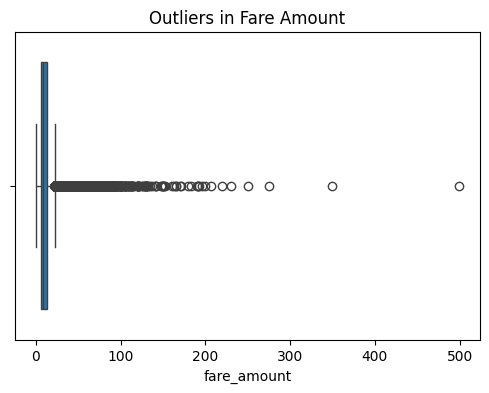

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare_amount'])
plt.title("Outliers in Fare Amount")
plt.show()

In [10]:
df = df[df['fare_amount'] < 100]

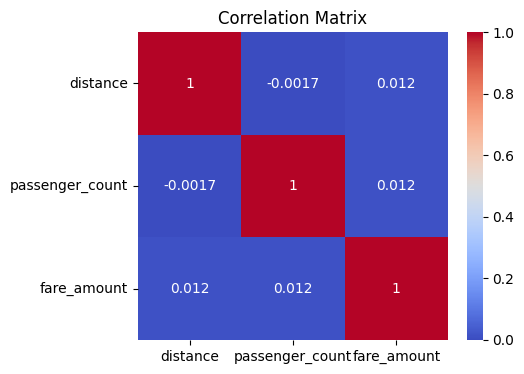

In [11]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [12]:
X = df[['distance', 'passenger_count']]
y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [33]:
def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse


r2_lr, rmse_lr = evaluate(y_test, y_pred_lr)
r2_rf, rmse_rf = evaluate(y_test, y_pred_rf)


print("Linear Regression → R2:", round(r2_lr, 4), ", RMSE:", round(rmse_lr, 4))
print("Random Forest     → R2:", round(r2_rf, 4), ", RMSE:", round(rmse_rf, 4))

Linear Regression → R2: -0.0042 , RMSE: 9.3623
Random Forest     → R2: 0.7053 , RMSE: 5.0721


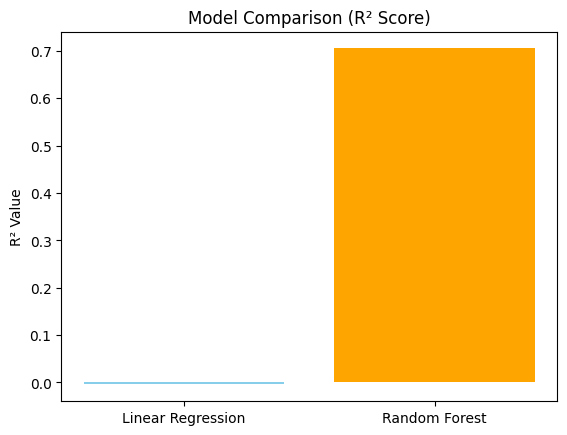

In [35]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_lr, r2_rf]

plt.bar(models, r2_scores, color=['skyblue', 'orange'])
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Value")
plt.show()